In [1]:
mapping = {
    'ShearTransform': 'Affine',
    'PerspectiveTransform': 'Perspective',
    'GridDistortionTransform': 'GridDistortion',
    'OpticalDistortionTransform': 'OpticalDistortion',
    'ShiftScaleRotateTransform': 'ShiftScaleRotate',
    'BrightnessContrastTransform': 'RandomBrightnessContrast',
    'HSVTransform': 'HueSaturationValue',
    'RGBShiftTransform': 'RGBShift',
    'GammaTransform': 'RandomGamma',
    'CLAHETransform': 'CLAHE',
    'SolarizeTransform': 'Solarize',
    'PosterizeTransform': 'Posterize',
    'EqualizeTransform': 'Equalize',
    'InvertTransform': 'InvertImg',
    'ToGrayTransform': 'ToGray',
    'ChannelShuffleTransform': 'ChannelShuffle',
    'ToSepiaTransform': 'ToSepia',
    'BlurTransform': 'Blur',
    'GaussianBlurTransform': 'GaussianBlur',
    'MedianBlurTransform': 'MedianBlur',
    'MotionBlurTransform': 'MotionBlur',
    'SharpenTransform': 'Sharpen',
    'EmbossTransform': 'Emboss',
    'GaussNoiseTransform': 'GaussNoise',
    'MultiplicativeNoiseTransform': 'MultiplicativeNoise',
    'ISONoiseTransform': 'ISONoise',
    'CoarseDropoutTransform': 'CoarseDropout',
    'GridDropoutTransform': 'GridDropout',
    'CompressionTransform': 'ImageCompression',
    'DownscaleTransform': 'Downscale',
    'PixelDropoutTransform': 'PixelDropout',
    'RainTransform': 'RandomRain',
    'SnowTransform': 'RandomSnow',
    'FogTransform': 'RandomFog',
    'ShadowTransform': 'RandomShadow',
    'SunFlareTransform': 'RandomSunFlare',
    'RainbowTransform': 'RandomToneCurve',
    'SpatterTransform': 'Spatter',
    'ChromaticAberrationTransform': 'ChromaticAberration',
    'DefocusTransform': 'Defocus',
    'ZoomBlurTransform': 'ZoomBlur',
    'MorphologicalTransform': 'Morphological',
    'ShotNoiseTransform': 'ShotNoise',
}

In [2]:
from pathlib import Path
import json
from collections import Counter
import matplotlib.pyplot as plt
import os

In [3]:
# model_name = 'CVPR2024-FAS'
# list_domains = ['cutout', 'figure', 'mannequin', 'mask', 'print', 'screen']

model_name = 'MVP-FAS similarity'
list_domains = ['figure similarity w=0,5', 'figure similarity w=0,3', 'figure similarity w=0,1']

path = Path(model_name)

In [7]:
best_transforms = []

for model_name in ['CVPR2024-FAS', 'DMFC-FAS', 'MVP-FAS']:
    path = Path(model_name)
    for domain in os.listdir(path):
        if '.png' not in domain and 'figure small augs v2' not in domain:
            with open(path / domain / 'best_params.json', 'r') as file:
                tmp_best_transforms = json.load(file)['best_transforms']
        
            best_transforms += tmp_best_transforms

counter = Counter(best_transforms)
counter = {mapping[key]: value for key, value in counter.items()}
counter

{'RandomRain': 5,
 'CoarseDropout': 5,
 'Blur': 2,
 'ImageCompression': 5,
 'ShiftScaleRotate': 4,
 'PixelDropout': 12,
 'OpticalDistortion': 6,
 'GridDropout': 12,
 'MotionBlur': 1,
 'Morphological': 7,
 'Defocus': 1,
 'Downscale': 9,
 'GaussianBlur': 3,
 'ZoomBlur': 1,
 'Sharpen': 6,
 'RGBShift': 3,
 'Perspective': 4,
 'RandomSnow': 1,
 'Emboss': 3,
 'MedianBlur': 2,
 'RandomGamma': 1,
 'ChromaticAberration': 3,
 'Equalize': 2,
 'Solarize': 1,
 'RandomToneCurve': 1,
 'MultiplicativeNoise': 3,
 'Posterize': 1}

In [51]:
# best_transforms = []

# for domain in list_domains:
#     with open(path / domain / 'best_params.json', 'r') as file:
#         tmp_best_transforms = json.load(file)['best_transforms']

#     best_transforms += tmp_best_transforms

# counter = Counter(best_transforms)
# counter

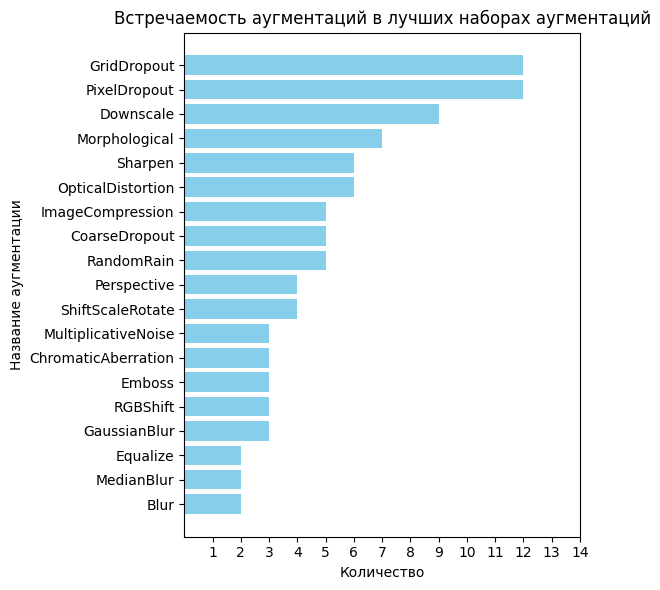

In [8]:
names = counter.keys()
values = counter.values()

# 1. Фильтрация (> 1) и 2. Сортировка в одной цепочке
# Сначала создаем пары, оставляем только те, где val > 1, затем сортируем
filtered_sorted = sorted(
    [(n, v) for n, v in zip(names, values) if v > 1], 
    key=lambda x: x[1]
)

# Разделяем обратно на два списка
names, values = zip(*filtered_sorted) if filtered_sorted else ([], [])
# names = [
#     'GridDropout',
#     'PixelDropout',
#     'Downscale'
# ]
# names = names[::-1]

plt.figure(figsize=(6, 6))
plt.barh(names, values, color='skyblue') # barh создает горизонтальные столбцы

plt.ylabel('Название аугментации')
plt.xlabel('Количество')
plt.title('Встречаемость аугментаций в лучших наборах аугментаций')
plt.tight_layout() # Автоматическая подгонка отступов
plt.xticks(range(1,15))

plt.savefig('counter_best_augmentations_config1.png', dpi=300, bbox_inches='tight')
# plt.savefig(path / 'counter_best_augmentations.png', dpi=300, bbox_inches='tight')
plt.show()